# 2단계 — 데이터 품질 진단

**목표:** 혼잡 지수를 만들기 전에, 이 데이터를 믿고 분석해도 되는지 검증한다.

**왜 필요한가:** 대부분의 분석은 "데이터는 정확하다"고 가정하고 시작한다.
그 가정이 틀리면 그 위에 쌓은 모든 결론이 무너진다.

**입력:** `data/processed/hourly_panel.parquet` (1단계 산출물)
**출력:** 품질 진단 결과 + 3단계에서 적용할 제외 규칙

---

### 이 단계에서 검증할 5가지

| 항목 | 확인할 질문 |
|---|---|
| ① 교차로 간 속도 체계 | 동막교가 2배 빠른 것은 실제인가, 센서 차이인가 |
| ② 물리적 비현실 값 | 도심에서 불가능한 속도가 있는가 |
| ③ 이동류별 신뢰도 | 유턴 데이터를 쓸 수 있는가 |
| ④ 저표본 구간 | 통행량이 거의 없는 시간대의 속도를 믿을 수 있는가 |
| ⑤ 결측 구간 | 동막교의 15.83% 공백을 어떻게 다룰 것인가 |

## 셀 1 — 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# 한글 폰트 (윈도우)
mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = BASE / 'data' / 'processed'

panel = pd.read_parquet(PROC / 'hourly_panel.parquet')
print('로드 완료:', panel.shape)
panel.head(3)

로드 완료: (531988, 18)


,교차로,AvenueSeq,접근로,MovementType,이동류,CollectedDate,교통량,대형차량,속도,대형차비율,연,월,일,시,요일,요일명,평일,날짜
0,동막교사거리,183,동막교삼거리 방면,1,직진,2023-11-07 16:00:00,1152,139,46.241318,0.120660,2023,11,7,16,1,화,True,2023-11-07
1,동막교사거리,183,동막교삼거리 방면,1,직진,2023-11-07 17:00:00,1243,118,42.220432,0.094932,2023,11,7,17,1,화,True,2023-11-07
2,동막교사거리,183,동막교삼거리 방면,1,직진,2023-11-07 18:00:00,1232,114,42.673710,0.092532,2023,11,7,18,1,화,True,2023-11-07


---
## 진단 ① — 교차로 간 속도 체계 비교

**문제:** 동막교사거리의 평균 속도가 다른 두 교차로의 약 2배다.
두 가지 가능성이 있다.

- **가능성 A:** 동막교는 실제로 원활한 도로다 → 정상 데이터
- **가능성 B:** 동막교 센서의 측정 기준이 다르다 → 보정 필요

이걸 확인하지 않고 세 교차로를 비교하면 "동막교가 가장 원활하다"는 잘못된 결론에 이른다.

### 1-1. 조건을 통제한 비교 (층화 비교)

혼합 효과를 제거하기 위해 **직진, 평일**로 조건을 맞춰 비교한다.

In [2]:
st = panel[(panel.이동류 == '직진') & (panel.평일)]

print('=== 직진·평일 기준 시간대별 평균 속도 (km/h) ===')
piv = st.pivot_table(index='시', columns='교차로', values='속도',
                     aggfunc='mean', observed=True)
display(piv.round(1))

print('\n=== 전체 평균 ===')
print(st.groupby('교차로', observed=True).속도.mean().round(1).to_string())

=== 직진·평일 기준 시간대별 평균 속도 (km/h) ===


교차로,동막교사거리,미금역사거리,오리삼거리
시,,,
0,45.299999,29.299999,23.799999
1,45.500000,29.200001,24.200001
2,45.900002,28.900000,24.600000
3,46.700001,29.799999,25.500000
4,45.500000,31.299999,25.100000
5,45.200001,31.700001,24.600000
6,47.700001,27.700001,26.000000
7,46.299999,26.400000,23.000000
8,45.000000,25.200001,22.799999



=== 전체 평균 ===
교차로
동막교사거리    44.200001
미금역사거리    26.299999
오리삼거리     23.500000


> **결과:** 조건을 통제해도 동막교 44.2 / 미금역 26.3 / 오리삼거리 23.5로 격차가 그대로다.
> 즉 차종이나 이동류 구성 차이 때문이 아니다. **다음으로 패턴의 '모양'을 봐야 한다.**

### 1-2. 정규화 후 패턴 비교 — 값이 아니라 모양을 본다

각 교차로의 최고 속도를 100으로 놓고 하루 변화 모양을 비교한다.
**크기가 아니라 형태가 다르다면**, 이는 단순한 도로 차이가 아니라 측정 체계 차이를 시사한다.

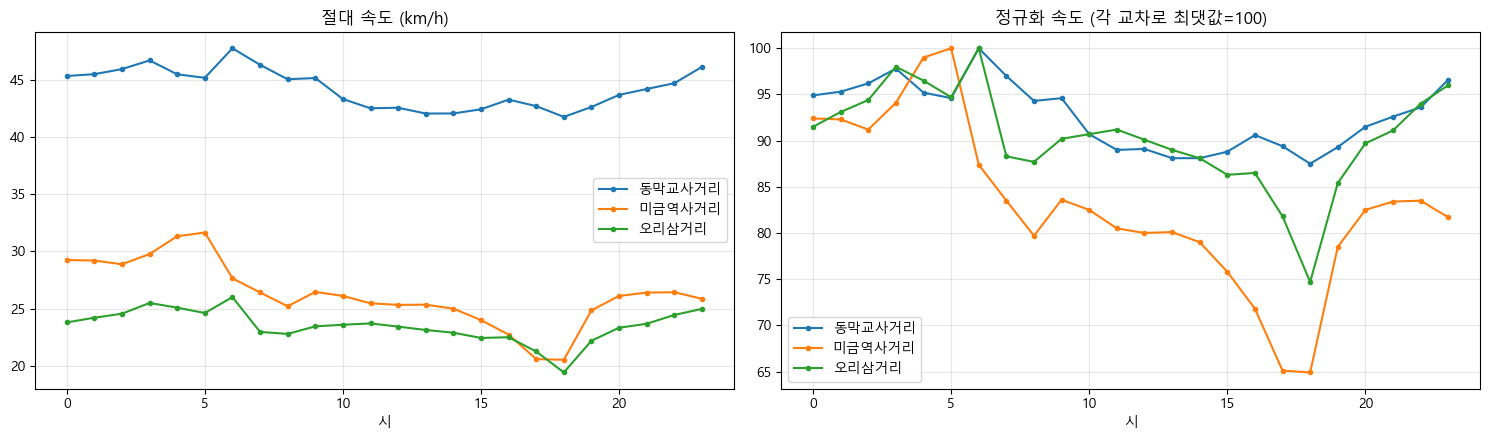

=== 하루 변동폭: (최대-최소)/최대 (%) ===
교차로
동막교사거리    12.500000
미금역사거리    35.099998
오리삼거리     25.299999

=== 저녁 피크(18시) 속도 저하: 최댓값 대비 (%) ===
교차로
동막교사거리    87.500000
미금역사거리    64.900002
오리삼거리     74.699997


In [3]:
norm = (piv / piv.max() * 100).round(1)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

for c in piv.columns:
    ax[0].plot(piv.index, piv[c], marker='o', ms=3, label=c)
ax[0].set_title('절대 속도 (km/h)'); ax[0].set_xlabel('시'); ax[0].legend(); ax[0].grid(alpha=.3)

for c in norm.columns:
    ax[1].plot(norm.index, norm[c], marker='o', ms=3, label=c)
ax[1].set_title('정규화 속도 (각 교차로 최댓값=100)'); ax[1].set_xlabel('시'); ax[1].legend(); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

print('=== 하루 변동폭: (최대-최소)/최대 (%) ===')
print(((piv.max() - piv.min()) / piv.max() * 100).round(1).to_string())

print('\n=== 저녁 피크(18시) 속도 저하: 최댓값 대비 (%) ===')
print((piv.loc[18] / piv.max() * 100).round(1).to_string())

> **핵심 발견:**
> - 미금역은 하루 변동폭 **35.1%**, 18시에 최고치의 64.9%까지 떨어진다 → 뚜렷한 러시아워 패턴
> - 오리삼거리는 변동폭 **25.3%**, 18시에 74.7% → 중간 정도의 러시아워 패턴
> - **동막교는 변동폭이 12.5%에 불과하고, 18시에도 87.5%를 유지** → 러시아워 영향이 거의 없음
>
> 즉 동막교는 **값만 큰 게 아니라 하루 패턴 자체가 평평하다.**
> 도심 간선도로에서 퇴근시간에도 속도가 거의 안 떨어지는 것은 이례적이다.

### 1-3. 교차로 내부의 일관성 확인

센서 문제라면 동막교의 **모든 접근로**가 고르게 빠를 것이고,
지점 특성이라면 접근로마다 편차가 있을 것이다.

In [4]:
appr = (st.groupby(['교차로', '접근로'], observed=True)
          .agg(평균속도=('속도', 'mean'), 평균교통량=('교통량', 'mean'), 표본수=('속도', 'size'))
          .round(1).sort_values(['교차로', '평균속도'], ascending=[True, False]))
display(appr)

print('=== 교차로 내 접근로 간 속도 편차 ===')
spread = st.groupby(['교차로', '접근로'], observed=True).속도.mean().groupby('교차로', observed=True).agg(['min', 'max'])
spread['배율'] = (spread['max'] / spread['min']).round(1)
print(spread.round(1).to_string())

평균속도  평균교통량    표본수
교차로    접근로                                 
동막교사거리 동막교삼거리 방면    54.299999  682.3   9466
       오리역 방면       46.799999  665.0   9476
       경기고속삼거리 방면   43.200001  102.0   9076
       오리공원 방면      32.400002   60.0   9252
미금역사거리 까치마을사거리 방면   66.400002  285.8   8937
       청송마을 사거리 방면  21.299999  475.6  11435
       정자일로 방면      13.200000  354.0  11439
       미금역 방면       12.700000  452.0  11203
오리삼거리  농수산물센터 방면    27.000000  610.5  11343
       오리역 방면       19.900000  606.1  10948

=== 교차로 내 접근로 간 속도 편차 ===
              min        max   배율
교차로                              
동막교사거리  32.400002  54.299999  1.7
미금역사거리  12.700000  66.400002  5.2
오리삼거리   19.900000  27.000000  1.4


> **중요한 반전:**
> 동막교 내부는 32.4 ~ 54.3km/h로 **1.7배** 편차인 반면,
> **미금역은 12.7 ~ 66.4km/h로 5.2배** 편차다.
> 특히 미금역 '까치마을사거리 방면'은 66.4km/h로 **동막교 평균보다도 빠르다.**
>
> **해석:** 동막교만 유별난 것이 아니라, **접근로마다 도로 성격이 크게 다르다.**
> 이는 "동막교 센서가 이상하다"기보다 **각 접근로의 물리적 조건(도로 등급, 신호 유무 등)이 다르다**는 증거에 가깝다.
>
> **결론:** 원인을 단정할 수 없으므로 데이터를 임의로 보정하지 않는다.
> 대신 **3단계에서 접근로별 자유속도를 각각 계산해 정규화**함으로써 이 문제를 구조적으로 해결한다.
> (절대속도로 비교하지 않으면 이 격차는 문제가 되지 않는다)

---
## 진단 ② — 물리적으로 비현실적인 값

교통공학 지식을 규칙으로 만들어 걸러낸다.

In [5]:
print('=== 속도 이상값 현황 ===')
for t in [80, 100, 120]:
    n = (panel.속도 > t).sum()
    print(f'{t}km/h 초과: {n:,}건 ({100*n/len(panel):.3f}%)')
print(f'속도 0: {(panel.속도 == 0).sum():,}건')

hi = panel[panel.속도 > 80]
print('\n=== 80km/h 초과 건의 특성 ===')
print('이동류별 분포:')
print(hi.이동류.value_counts().to_string())
print(f'\n교통량 중앙값: {hi.교통량.median():.0f}대 (전체 중앙값 {panel.교통량.median():.0f}대)')

=== 속도 이상값 현황 ===
80km/h 초과: 13,011건 (2.446%)
100km/h 초과: 5,139건 (0.966%)
120km/h 초과: 2,553건 (0.480%)
속도 0: 192건

=== 80km/h 초과 건의 특성 ===
이동류별 분포:
이동류
유턴     8833
직진     2851
우회전     979
좌회전     348

교통량 중앙값: 13대 (전체 중앙값 73대)


> **결과 해석:**
> 80km/h 초과가 13,011건(2.4%)인데, **그중 8,833건(68%)이 유턴**이다.
> 유턴은 물리적으로 가장 느려야 하는 이동류인데 가장 빠르게 기록되어 있다.
>
> 또한 이 건들의 교통량 중앙값은 **13대**로, 전체 중앙값 73대의 5분의 1 수준이다.
> → **통행량이 적을 때 속도가 비정상적으로 크게 나온다**는 패턴이 확인된다.

---
## 진단 ③ — 이동류별 신뢰도 (유턴 제외 근거)

,행수,평균교통량,평균속도,속도중앙값
이동류,,,,
우회전,141623,99.6,15.100000,12.900000
유턴,115849,17.9,39.700001,34.799999
좌회전,130965,112.0,24.400000,15.600000
직진,143551,419.3,32.400002,27.299999


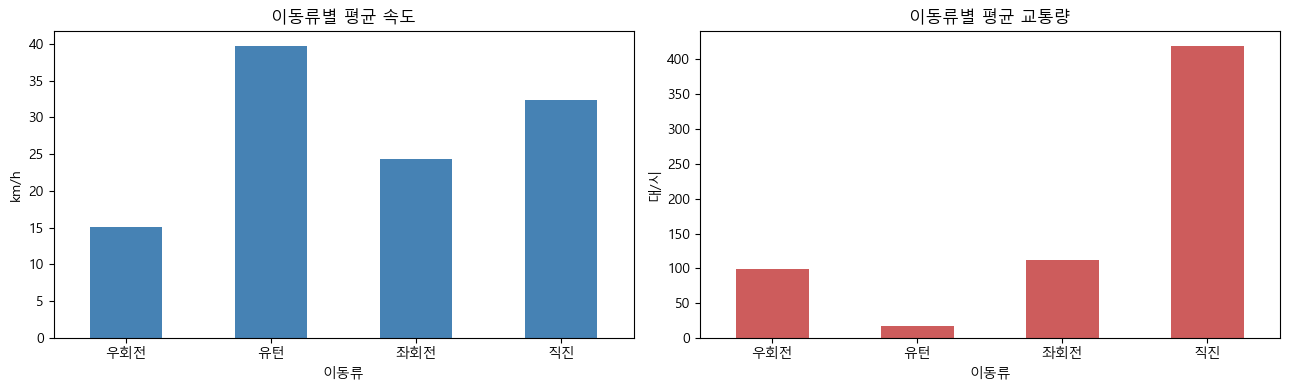

In [6]:
mv = (panel.groupby('이동류', observed=True)
           .agg(행수=('교통량', 'size'),
                평균교통량=('교통량', 'mean'),
                평균속도=('속도', 'mean'),
                속도중앙값=('속도', 'median'))
           .round(1))
display(mv)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
mv.평균속도.plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('이동류별 평균 속도'); ax[0].set_ylabel('km/h'); ax[0].tick_params(axis='x', rotation=0)
mv.평균교통량.plot(kind='bar', ax=ax[1], color='indianred')
ax[1].set_title('이동류별 평균 교통량'); ax[1].set_ylabel('대/시'); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

> **유턴을 제외하는 근거 (두 가지 모두 충족):**
>
> 1. **물리적 비현실성** — 유턴 평균 39.7km/h로 직진(32.4)보다 빠르다. 실제 도로에서 불가능하다.
> 2. **표본 과소** — 유턴 평균 교통량 17.9대/시로, 직진(419.3대)의 4% 수준이다.
>
> 좁은 회전 반경을 도는 유턴이 직진보다 빠를 수는 없으므로, **차량 재인식 과정의 오류로 판단**한다.
> → **3단계 이후 분석에서 유턴을 제외**하고, 그 사유를 리포트에 명시한다.

---
## 진단 ④ — 저표본 구간의 속도 신뢰도

통행량이 극히 적은 시간대의 평균 속도는 소수 차량에 좌우되어 불안정하다.

In [7]:
print('=== 교통량 구간별 평균 속도 ===')
rows = []
for t in [1, 3, 5, 10, 20]:
    sub = panel[panel.교통량 <= t]
    rows.append({'조건': f'{t}대 이하', '비율(%)': round(100*len(sub)/len(panel), 2),
                 '평균속도': round(sub.속도.mean(), 1), '속도표준편차': round(sub.속도.std(), 1)})
rows.append({'조건': '전체', '비율(%)': 100.0,
             '평균속도': round(panel.속도.mean(), 1), '속도표준편차': round(panel.속도.std(), 1)})
display(pd.DataFrame(rows))

# 교통량과 속도 변동성의 관계
bins = [0, 1, 5, 10, 30, 100, 300, 10000]
panel['교통량구간'] = pd.cut(panel.교통량, bins=bins)
g = panel.groupby('교통량구간', observed=True).속도.agg(['mean', 'std', 'size']).round(1)
display(g)

=== 교통량 구간별 평균 속도 ===


,조건,비율(%),평균속도,속도표준편차
0,1대 이하,3.29,33.099998,32.8
1,3대 이하,7.94,32.599998,29.1
2,5대 이하,11.45,32.299999,27.5
3,10대 이하,18.35,32.000000,25.7
4,20대 이하,28.96,31.600000,24.5
5,전체,100.00,27.400000,21.0


,mean,std,size
교통량구간,,,
"(0, 1]",33.099998,32.799999,17524
"(1, 5]",31.900000,25.000000,43388
"(5, 10]",31.700001,22.500000,36732
"(10, 30]",30.400000,22.000000,92404
"(30, 100]",28.100000,20.900000,115577
"(100, 300]",22.000000,17.700001,137882
"(300, 10000]",26.900000,16.500000,88481


> **결과:** 교통량 1대 이하 구간(전체의 3.29%)의 평균 속도는 33.1km/h로 전체 평균 27.4km/h보다 **높다.**
> 통행이 거의 없을 때 속도가 과대 기록되는 경향이 확인된다.
>
> **처리 방침:** 3단계에서 자유속도를 계산할 때 **교통량 하위 25% 구간**을 쓰기로 했는데,
> 이 저표본 왜곡이 섞이지 않도록 **최소 교통량 조건**을 함께 적용한다.

---
## 진단 ⑤ — 결측 구간의 처리 방침

1단계에서 확인한 동막교의 15.83% 결측을 어떻게 다룰지 결정한다.

=== 월별 데이터 보유 현황 (관측된 시간 수) ===


교차로,동막교사거리,미금역사거리,오리삼거리
CollectedDate,,,
2023-11,560,560,560
2023-12,744,744,744
2024-01,744,744,744
2024-02,696,696,696
2024-03,744,744,744
2024-04,716,716,716
2024-05,744,744,744
2024-06,720,720,720
2024-07,744,744,744


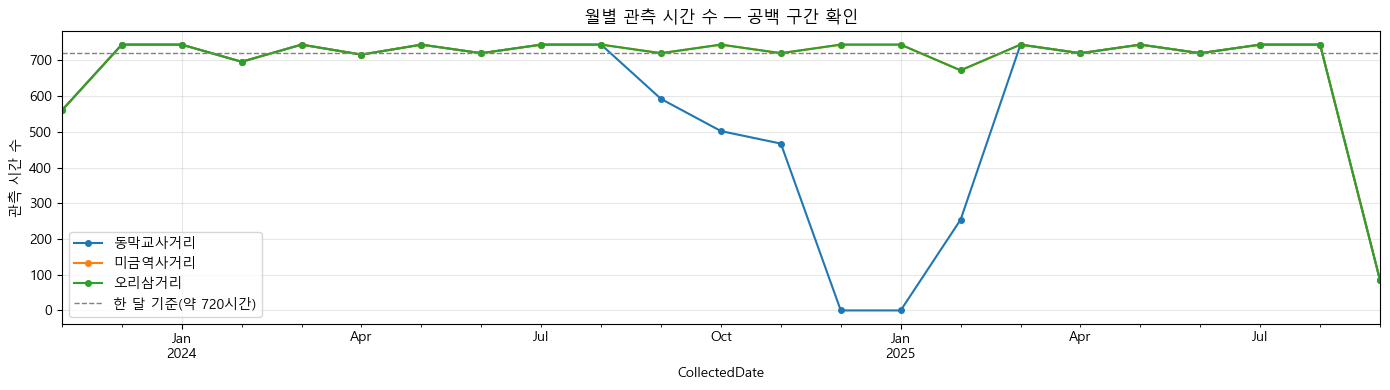

In [8]:
INTERSECTIONS = ['미금역사거리', '동막교사거리', '오리삼거리']

print('=== 월별 데이터 보유 현황 (관측된 시간 수) ===')
cov = (panel.groupby([panel.CollectedDate.dt.to_period('M'), '교차로'], observed=True)
            .CollectedDate.nunique().unstack(fill_value=0))
display(cov)

fig, ax = plt.subplots(figsize=(14, 4))
cov.plot(ax=ax, marker='o', ms=4)
ax.axhline(720, color='gray', ls='--', lw=1, label='한 달 기준(약 720시간)')
ax.set_title('월별 관측 시간 수 — 공백 구간 확인')
ax.set_ylabel('관측 시간 수'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

> **처리 방침 (결측을 채우지 않는다):**
>
> 동막교의 결측은 2024년 10월~2025년 2월에 집중된 **연속 구간(96.7%)** 이다.
> 산발적 결측이라면 보간(interpolation)이 가능하지만,
> **5개월에 가까운 연속 공백은 추정할 근거가 없다.** 억지로 채우면 없는 패턴을 만들어내게 된다.
>
> 따라서:
> - 결측 구간은 **그대로 비워둔다** (분석에서 자연 제외)
> - **5단계 학습·검증 분할 시 이 공백을 피해서** 기간을 설정한다
> - 교차로 간 비교 시 **동일 기간으로 맞춰서** 비교한다

---
## 종합 — 3단계에 적용할 제외 규칙 확정

In [9]:
print('=== 제외 규칙 적용 전후 비교 ===')

before = len(panel)

# 규칙 1: 유턴 제외 (물리적 비현실 + 표본 과소)
r1 = panel[panel.이동류 != '유턴']

# 규칙 2: 물리적 비현실 속도 제외 (도심 교차로 기준 80km/h 초과)
r2 = r1[r1.속도 <= 80]

# 규칙 3: 속도 0 제외 (측정 실패로 판단)
r3 = r2[r2.속도 > 0]

clean = r3.copy()

print(f'원본                : {before:,}행')
print(f'① 유턴 제외 후      : {len(r1):,}행  (-{before-len(r1):,}, {100*(before-len(r1))/before:.1f}%)')
print(f'② 속도>80 제외 후   : {len(r2):,}행  (-{len(r1)-len(r2):,}, {100*(len(r1)-len(r2))/before:.1f}%)')
print(f'③ 속도=0 제외 후    : {len(r3):,}행  (-{len(r2)-len(r3):,})')
print(f'\n최종                : {len(clean):,}행 (원본의 {100*len(clean)/before:.1f}%)')

print('\n=== 정제 후 값 범위 확인 ===')
print(f'속도: {clean.속도.min():.1f} ~ {clean.속도.max():.1f} km/h (평균 {clean.속도.mean():.1f})')
print(f'교통량: {clean.교통량.min()} ~ {clean.교통량.max()} 대/시')
print('\n이동류별 평균 속도:')
print(clean.groupby('이동류', observed=True).속도.mean().round(1).to_string())

=== 제외 규칙 적용 전후 비교 ===
원본                : 531,988행
① 유턴 제외 후      : 416,139행  (-115,849, 21.8%)
② 속도>80 제외 후   : 411,961행  (-4,178, 0.8%)
③ 속도=0 제외 후    : 411,821행  (-140)

최종                : 411,821행 (원본의 77.4%)

=== 정제 후 값 범위 확인 ===
속도: 0.5 ~ 80.0 km/h (평균 23.2)
교통량: 1 ~ 1787 대/시

이동류별 평균 속도:
이동류
우회전    14.500000
좌회전    24.200001
직진     31.000000


> **주의:** 여기서 제외한 것은 **분석 대상에서 빼는 것**이지 데이터를 수정하는 것이 아니다.
> 제외 사유가 모두 근거(물리 법칙 위반, 표본 과소)에 기반하며, 리포트에 명시한다.
>
> 특히 **1단계에서 논의한 IQR 방식의 무조건적 이상치 제거는 쓰지 않는다.**
> 극단값이 실제 교통 변동일 수 있기 때문이며, 이는 이전 프로젝트에서 확인한 교훈이다.

## 셀 — 정제 데이터 저장

In [10]:
clean = clean.drop(columns=['교통량구간'], errors='ignore')

out = PROC / 'hourly_panel_clean.parquet'
clean.to_parquet(out, index=False)

print(f'저장 완료: {out}')
print(f'파일 크기: {out.stat().st_size/1024**2:.1f} MB')
print(f'행 수: {len(clean):,}')

check = pd.read_parquet(out)
print('재로드 검증:', check.shape, '— 정상' if check.shape == clean.shape else '— 오류')

저장 완료: C:\Users\chpar\Exercise_CP\work\파란학기 응용\data\processed\hourly_panel_clean.parquet
파일 크기: 4.7 MB
행 수: 411,821
재로드 검증: (411821, 18) — 정상


---
# 2단계 완료

### 진단 결과 요약

| 항목 | 발견 | 조치 |
|---|---|---|
| 교차로 간 속도 격차 | 동막교 44.2 vs 미금역 26.3 (2배). 단 미금역 내부 편차가 5.2배로 더 큼 | 보정하지 않고 **접근로별 정규화**로 해결 (3단계) |
| 동막교 패턴 이상 | 하루 변동폭 12.5%로 러시아워 영향 거의 없음 | 리포트에 특성으로 기록 |
| 유턴 데이터 | 평균 39.7km/h로 직진보다 빠름, 교통량은 직진의 4% | **분석에서 제외** |
| 속도 80km/h 초과 | 13,011건, 그중 68%가 유턴 | **제외** |
| 저표본 구간 | 교통량 1대 이하일 때 속도 과대(33.1 vs 27.4) | 자유속도 계산 시 최소 교통량 조건 적용 |
| 동막교 결측 | 15.83%, 2024.10~2025.2 연속 | **보간하지 않음**, 5단계 분할 시 회피 |

### 산출물
- `data/processed/hourly_panel_clean.parquet` — 제외 규칙이 적용된 분석용 데이터

### 이 단계의 핵심 메시지 (포트폴리오 서술용)

> "동막교의 속도가 2배로 나타나 센서 오류를 의심했으나, 조건을 통제하고 접근로별로 분해한 결과
> **미금역 내부 편차(5.2배)가 더 크다는 사실**을 발견했다.
> 즉 문제는 특정 센서가 아니라 **접근로마다 도로 조건이 다르다는 구조적 특성**이었다.
> 따라서 데이터를 임의 보정하는 대신, 각 접근로의 자유속도를 기준으로 정규화하는 방식으로 해결했다."

---

### 다음 단계
**3단계 — 혼잡 지수 정의:** 자유속도 대비 저하율로 혼잡을 정의하고, 임계값을 검증으로 결정한다.